# 03 — Exploratory Data Analysis and Visualisation

**Course:** COMP4381 — Data Science and Analytics  
**Semester:** Spring 2026  
**Owner:** Mohammad Hmaid (1230302)  

---

## Purpose

This notebook performs exploratory data analysis (EDA) on the cleaned flight delay dataset
produced by `02_cleaning.ipynb`. Its goals are:

1. **Summarise** the dataset with descriptive statistics for both numeric and categorical features.
2. **Analyse the target variable** — examine its distribution, identify zero-inflation, and decide
   whether regression or classification is the appropriate modelling task.
3. **Visualise** relationships between delay and key factors (country, season, airport type,
   traffic volume, geographic location, and delay causes) with at least 7 publication-quality figures.
4. **Interpret** each finding, connecting it to domain knowledge about the ATFM system and
   European aviation.
5. **Summarise key findings** and recommend a target variable and modelling strategy for Phase 4.

**Input:** `data/processed/flight_delays_clean.csv` (103,466 rows × 39 columns)  
**Output:** 8 figures saved to `figures/`

## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Paths ---
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "flight_delays_clean.csv"
assert INPUT_PATH.exists(), f"Input file not found: {INPUT_PATH}"

# --- Plot style ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

# --- Load data ---
df = pd.read_csv(INPUT_PATH, parse_dates=["date"])
print(f"Loaded: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Countries: {df['country'].nunique()}  |  Airports: {df['icao_code'].nunique()}")

Loaded: 103,466 rows  x  39 columns
Date range: 2023-01-01 to 2024-12-31
Countries: 5  |  Airports: 147


## 2. Descriptive Statistics

### 2.1 Numeric Features

We begin with the standard five-number summary plus mean and standard deviation
for every numeric column. This gives an immediate sense of central tendency, spread,
and skewness.

In [2]:
# Select numeric columns that are meaningful features (exclude encoded duplicates)
numeric_cols = [
    "arrivals", "departures", "total_movements",
    "total_atfm_delay_min", "avg_atfm_delay_min", "pct_delayed_15",
    "flights_with_delay", "flights_delayed_15",
    "delay_weather_min", "delay_capacity_min", "delay_staffing_min",
    "latitude_deg", "longitude_deg", "elevation_ft",
    "runway_count", "max_runway_length_ft",
    "scheduled_service", "is_weekend", "is_summer", "hub_flag",
]

desc = df[numeric_cols].describe().T
desc["skewness"] = df[numeric_cols].skew()
desc["kurtosis"] = df[numeric_cols].kurtosis()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
arrivals,103466.0,55.51,69.51,0.00,6.00,18.00,88.00,211.00,1.27,0.19
departures,103466.0,55.41,69.52,0.00,6.00,18.00,88.00,211.00,1.27,0.19
total_movements,103466.0,111.08,139.34,0.00,11.00,36.00,176.00,423.50,1.27,0.20
total_atfm_delay_min,103466.0,69.00,476.45,0.00,0.00,0.00,0.00,8835.04,12.32,184.76
avg_atfm_delay_min,103466.0,0.29,1.76,0.00,0.00,0.00,0.00,30.95,10.86,147.42
pct_delayed_15,103466.0,0.64,3.56,0.00,0.00,0.00,0.00,51.86,8.75,92.87
flights_with_delay,103466.0,3.68,21.33,0.00,0.00,0.00,0.00,509.00,9.20,103.43
flights_delayed_15,103466.0,1.57,11.26,0.00,0.00,0.00,0.00,440.00,13.63,249.32
delay_weather_min,103466.0,38.53,461.24,0.00,0.00,0.00,0.00,14782.00,20.51,518.32
delay_capacity_min,103466.0,4.58,53.05,0.00,0.00,0.00,0.00,1764.00,18.76,452.05


**Observations from the numeric summary:**

- **Delay columns are heavily right-skewed.** The median of `avg_atfm_delay_min` is 0.00 while
  the mean is 0.29 and the max is ~31 minutes. This pattern — median at zero, long right tail — 
  is the signature of a **zero-inflated distribution**, which makes sense because most airport-days
  experience no ATFM delay at all.
- **Traffic columns** (`arrivals`, `departures`) have a wide range from 0 to 211 (capped). 
  The median (18) is far below the mean (55.5), indicating a right-skewed distribution driven
  by a few very busy hub airports.
- **Geographic spread** is reasonable: latitude ranges from ~28° (Canary Islands) to ~57° (Scotland),
  and longitude from ~–18° (Canary Islands) to ~14° (eastern Germany).

### 2.2 Categorical Features

In [3]:
cat_cols = ["country", "type", "season", "traffic_volume_class", "primary_surface"]

for col in cat_cols:
    print(f"--- {col} ---")
    vc = df[col].value_counts()
    total = len(df)
    for val, count in vc.items():
        print(f"  {val:<25} {count:>7,}  ({count/total*100:5.1f}%)")
    print()

--- country ---
  France                     43,572  ( 42.1%)
  Spain                      31,521  ( 30.5%)
  United Kingdom             13,875  ( 13.4%)
  Germany                    10,941  ( 10.6%)
  Netherlands                 3,557  (  3.4%)

--- type ---
  medium_airport             53,891  ( 52.1%)
  large_airport              49,575  ( 47.9%)

--- season ---
  summer                     26,256  ( 25.4%)
  spring                     26,091  ( 25.2%)
  autumn                     25,865  ( 25.0%)
  winter                     25,254  ( 24.4%)

--- traffic_volume_class ---
  high                       35,676  ( 34.5%)
  medium                     35,542  ( 34.4%)
  low                        32,248  ( 31.2%)

--- primary_surface ---
  asphalt                    89,117  ( 86.1%)
  concrete                   11,623  ( 11.2%)
  other                       2,109  (  2.0%)
  grass                         617  (  0.6%)



**Observations from the categorical summary:**

- **Country distribution is imbalanced.** France dominates (42.1%), followed by Spain (30.5%).
  The Netherlands contributes only 3.4% because it has just 5 airports in the EUROCONTROL dataset.
  This imbalance reflects the actual number of airports per country, not a sampling bias.
- **Airport type** is roughly balanced between medium (52.1%) and large (47.9%) airports.
- **Seasons** are nearly evenly split (~25% each), as expected from two full calendar years.
- **Traffic volume class** is roughly balanced thanks to the quantile-based binning in Notebook 01.
- **Surface type** is dominated by asphalt (86.1%), reflecting that almost all commercial airports
  use asphalt or a similar paved surface.

---

## 3. Target Variable Analysis

The central question of this analysis is: **what should we predict?**

Our dataset contains two candidate target variables, both derived from EUROCONTROL's
ATFM (Air Traffic Flow Management) delay data:

- `avg_atfm_delay_min` — average ATFM arrival delay per flight on that airport-day (continuous)
- `pct_delayed_15` — percentage of arriving flights delayed more than 15 minutes (continuous, 0–100)

The 15-minute threshold is the **OTP15 standard** used by EUROCONTROL and most European
civil aviation authorities: a flight is considered "on time" if it arrives within 15 minutes
of its scheduled time.

Before choosing between regression and classification, we need to understand the distribution
of these variables.

In [4]:
# --- Target variable distribution analysis ---
targets = ["avg_atfm_delay_min", "pct_delayed_15", "total_atfm_delay_min"]

print("=" * 70)
print("TARGET VARIABLE DISTRIBUTION ANALYSIS")
print("=" * 70)

for col in targets:
    total = len(df)
    n_zero = (df[col] == 0).sum()
    n_nonzero = total - n_zero
    nonzero = df[col][df[col] > 0]

    print(f"\n--- {col} ---")
    print(f"  Total rows:          {total:>10,}")
    print(f"  Zero rows:           {n_zero:>10,}  ({n_zero/total*100:.1f}%)")
    print(f"  Non-zero rows:       {n_nonzero:>10,}  ({n_nonzero/total*100:.1f}%)")
    if len(nonzero) > 0:
        print(f"  Non-zero mean:       {nonzero.mean():>10.2f}")
        print(f"  Non-zero median:     {nonzero.median():>10.2f}")
        print(f"  Non-zero std:        {nonzero.std():>10.2f}")
        print(f"  Non-zero max:        {nonzero.max():>10.2f}")
        print(f"  Skewness (all):      {df[col].skew():>10.2f}")
        print(f"  Skewness (non-zero): {nonzero.skew():>10.2f}")

TARGET VARIABLE DISTRIBUTION ANALYSIS

--- avg_atfm_delay_min ---
  Total rows:             103,466
  Zero rows:               93,809  (90.7%)
  Non-zero rows:            9,657  (9.3%)
  Non-zero mean:             3.14
  Non-zero median:           1.42
  Non-zero std:              4.93
  Non-zero max:             30.95
  Skewness (all):           10.86
  Skewness (non-zero):       3.38

--- pct_delayed_15 ---
  Total rows:             103,466
  Zero rows:               95,066  (91.9%)
  Non-zero rows:            8,400  (8.1%)
  Non-zero mean:             7.82
  Non-zero median:           4.13
  Non-zero std:              9.98
  Non-zero max:             51.86
  Skewness (all):            8.75
  Skewness (non-zero):       2.35

--- total_atfm_delay_min ---
  Total rows:             103,466
  Zero rows:               93,809  (90.7%)
  Non-zero rows:            9,657  (9.3%)
  Non-zero mean:           739.24
  Non-zero median:         239.00
  Non-zero std:           1391.73
  Non-zero ma

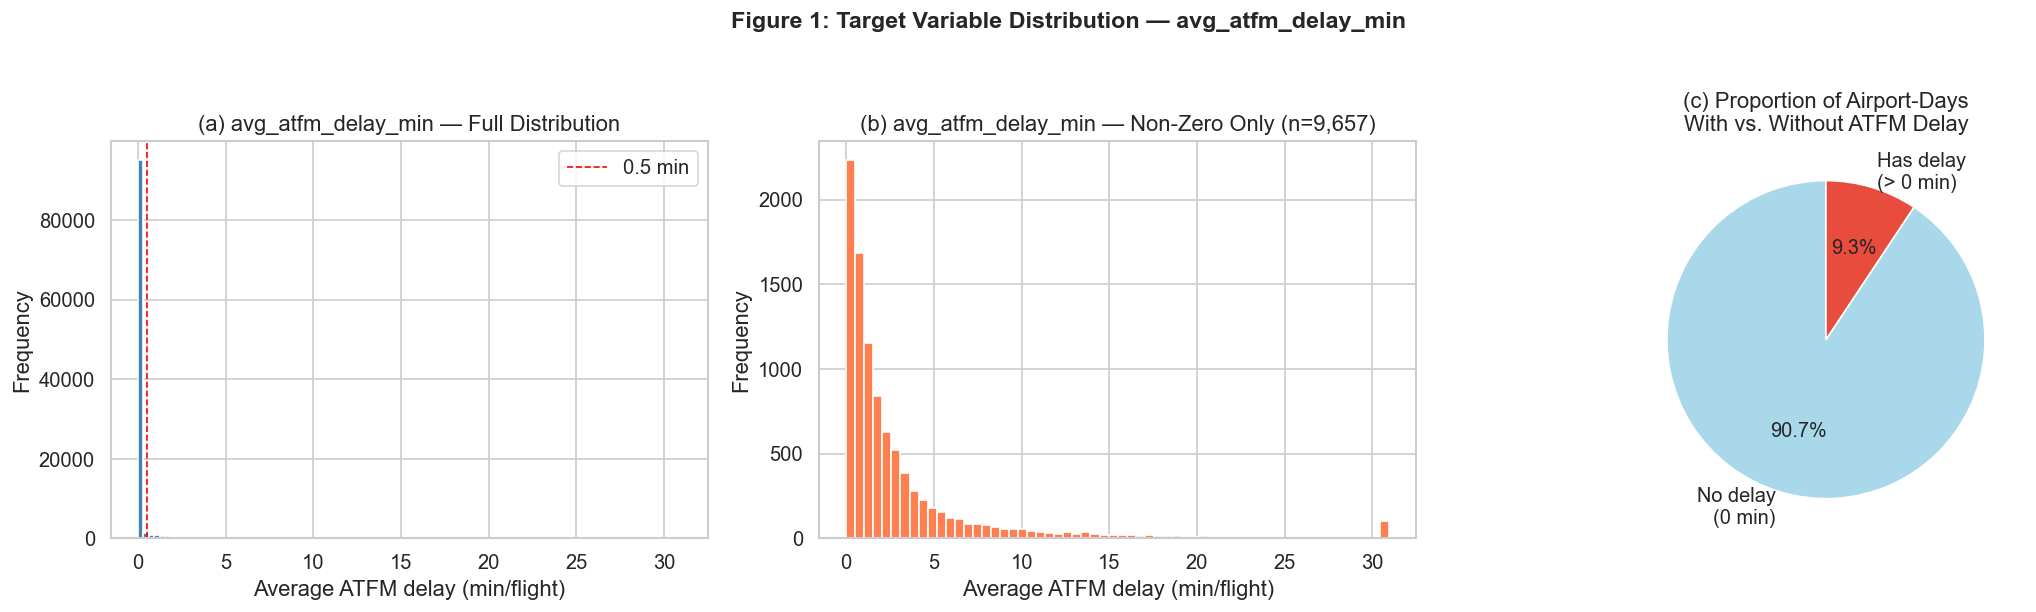

Saved: ..\figures\fig1_target_distribution.png


In [5]:
# --- Figure 1: Target variable distribution ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Full distribution of avg_atfm_delay_min (including zeros)
axes[0].hist(df["avg_atfm_delay_min"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_title("(a) avg_atfm_delay_min — Full Distribution")
axes[0].set_xlabel("Average ATFM delay (min/flight)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(x=0.5, color="red", linestyle="--", linewidth=1, label="0.5 min")
axes[0].legend()

# Panel B: Non-zero values only
nonzero_delay = df["avg_atfm_delay_min"][df["avg_atfm_delay_min"] > 0]
axes[1].hist(nonzero_delay, bins=60, color="coral", edgecolor="white")
axes[1].set_title(f"(b) avg_atfm_delay_min — Non-Zero Only (n={len(nonzero_delay):,})")
axes[1].set_xlabel("Average ATFM delay (min/flight)")
axes[1].set_ylabel("Frequency")

# Panel C: Pie chart showing zero vs non-zero proportions
n_zero = (df["avg_atfm_delay_min"] == 0).sum()
n_nonzero = len(df) - n_zero
axes[2].pie(
    [n_zero, n_nonzero],
    labels=["No delay\n(0 min)", "Has delay\n(> 0 min)"],
    autopct="%1.1f%%",
    colors=["#a8d8ea", "#e74c3c"],
    startangle=90,
    textprops={"fontsize": 12},
)
axes[2].set_title("(c) Proportion of Airport-Days\nWith vs. Without ATFM Delay")

plt.suptitle("Figure 1: Target Variable Distribution — avg_atfm_delay_min",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig1_target_distribution.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig1_target_distribution.png'}")

### Interpretation of Figure 1

The distribution of `avg_atfm_delay_min` reveals a **strongly zero-inflated** pattern:
approximately 90.7% of all airport-days have exactly zero ATFM delay. This is not a
data quality issue — it reflects the real operation of the ATFM system. EUROCONTROL's
Network Manager only imposes ATFM regulations (and thus delay) when demand at an
airport or in an en-route sector exceeds the declared capacity. On a typical day, most
airports in our five countries operate within capacity and no ATFM delay is imposed.

Panel (b) shows that among the ~9,657 airport-days that **do** experience delay, the
distribution is still right-skewed: most delayed days have a moderate average delay
(1–5 min/flight), while a smaller number of days see severe average delays above 10 min/flight.

**Implication for modelling:** A standard regression model trained on this data would
learn to predict zero for almost every input and still achieve a low MAE, but it would
fail completely at identifying the days that actually matter. This zero-inflation strongly
favours **binary classification** (predicting "delay day" vs. "no delay day") over
regression.

---

## 4. Target Variable Decision

### Binary classification target: `has_atfm_delay`

Based on the distribution analysis above, we define a binary target variable:

$$\text{has\_atfm\_delay} = \begin{cases} 1 & \text{if } \text{total\_atfm\_delay\_min} > 0 \\ 0 & \text{otherwise} \end{cases}$$

An airport-day receives label 1 if EUROCONTROL imposed **any** ATFM arrival delay at all.
This aligns with the operational question: *"Will this airport experience ATFM flow
restrictions tomorrow?"*

In [6]:
# Create the binary target
df["has_atfm_delay"] = (df["total_atfm_delay_min"] > 0).astype(int)

# Class balance
n_pos = df["has_atfm_delay"].sum()
n_neg = len(df) - n_pos
ratio = n_neg / n_pos

print("Binary target: has_atfm_delay")
print(f"  Class 0 (no delay):  {n_neg:>7,}  ({n_neg/len(df)*100:.1f}%)")
print(f"  Class 1 (has delay): {n_pos:>7,}  ({n_pos/len(df)*100:.1f}%)")
print(f"  Imbalance ratio:     {ratio:.1f} : 1")
print()
print("This is an imbalanced binary classification problem.")
print("In Phase 4, we will need to use stratified splitting, class weighting,")
print("and evaluation metrics beyond accuracy (precision, recall, F1, AUC-ROC).")

Binary target: has_atfm_delay
  Class 0 (no delay):   93,809  (90.7%)
  Class 1 (has delay):   9,657  (9.3%)
  Imbalance ratio:     9.7 : 1

This is an imbalanced binary classification problem.
In Phase 4, we will need to use stratified splitting, class weighting,
and evaluation metrics beyond accuracy (precision, recall, F1, AUC-ROC).


---

## 5. Visualisations

For the remaining visualisations, we frequently work with **aggregated views** rather than
raw daily rows, because 90.7% of the daily rows have zero delay and would obscure patterns.
Common aggregation levels:

- **Airport-level:** one row per airport (147 airports), used for geographic and type-based comparisons.
- **Country-month level:** one row per country per calendar month (5 × 24 = 120 rows), used for seasonal trends.

We also define a useful derived metric — the **delay rate** — which is the proportion of an
airport's operating days that experienced any ATFM delay.

### 5.1 Pre-compute Aggregated Tables

In [7]:
# --- Airport-level aggregation ---
airport_agg = df.groupby("icao_code").agg(
    country=("country", "first"),
    type=("type", "first"),
    latitude_deg=("latitude_deg", "first"),
    longitude_deg=("longitude_deg", "first"),
    elevation_ft=("elevation_ft", "first"),
    hub_flag=("hub_flag", "first"),
    runway_count=("runway_count", "first"),
    max_runway_length_ft=("max_runway_length_ft", "first"),
    mean_arrivals=("arrivals", "mean"),
    mean_departures=("departures", "mean"),
    mean_delay=("avg_atfm_delay_min", "mean"),
    total_delay=("total_atfm_delay_min", "sum"),
    delay_days=("has_atfm_delay", "sum"),
    total_days=("has_atfm_delay", "count"),
    mean_weather_delay=("delay_weather_min", "mean"),
    mean_capacity_delay=("delay_capacity_min", "mean"),
    mean_staffing_delay=("delay_staffing_min", "mean"),
).reset_index()

airport_agg["delay_rate"] = airport_agg["delay_days"] / airport_agg["total_days"]

print(f"Airport-level table: {airport_agg.shape[0]} airports")
print(f"Delay rate range: {airport_agg['delay_rate'].min():.1%} to {airport_agg['delay_rate'].max():.1%}")
print(f"Delay rate mean:  {airport_agg['delay_rate'].mean():.1%}")

# --- Country-month aggregation ---
df["year_month"] = df["date"].dt.to_period("M")

country_month = df.groupby(["country", "year_month"]).agg(
    mean_delay=("avg_atfm_delay_min", "mean"),
    total_delay=("total_atfm_delay_min", "sum"),
    delay_rate=("has_atfm_delay", "mean"),
    mean_arrivals=("arrivals", "mean"),
    total_rows=("has_atfm_delay", "count"),
).reset_index()

country_month["year_month_dt"] = country_month["year_month"].dt.to_timestamp()

print(f"\nCountry-month table: {country_month.shape[0]} rows")

Airport-level table: 147 airports
Delay rate range: 0.0% to 90.3%
Delay rate mean:  9.0%

Country-month table: 120 rows


### 5.2 Figure 2 — Delay Rate by Country

The delay rate (proportion of airport-days that experience any ATFM delay) is a more
informative metric than raw delay minutes when comparing countries, because it is not
dominated by a few extreme delay days at major hubs.

C:\Users\abdal\AppData\Local\Temp\ipykernel_15720\750012499.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


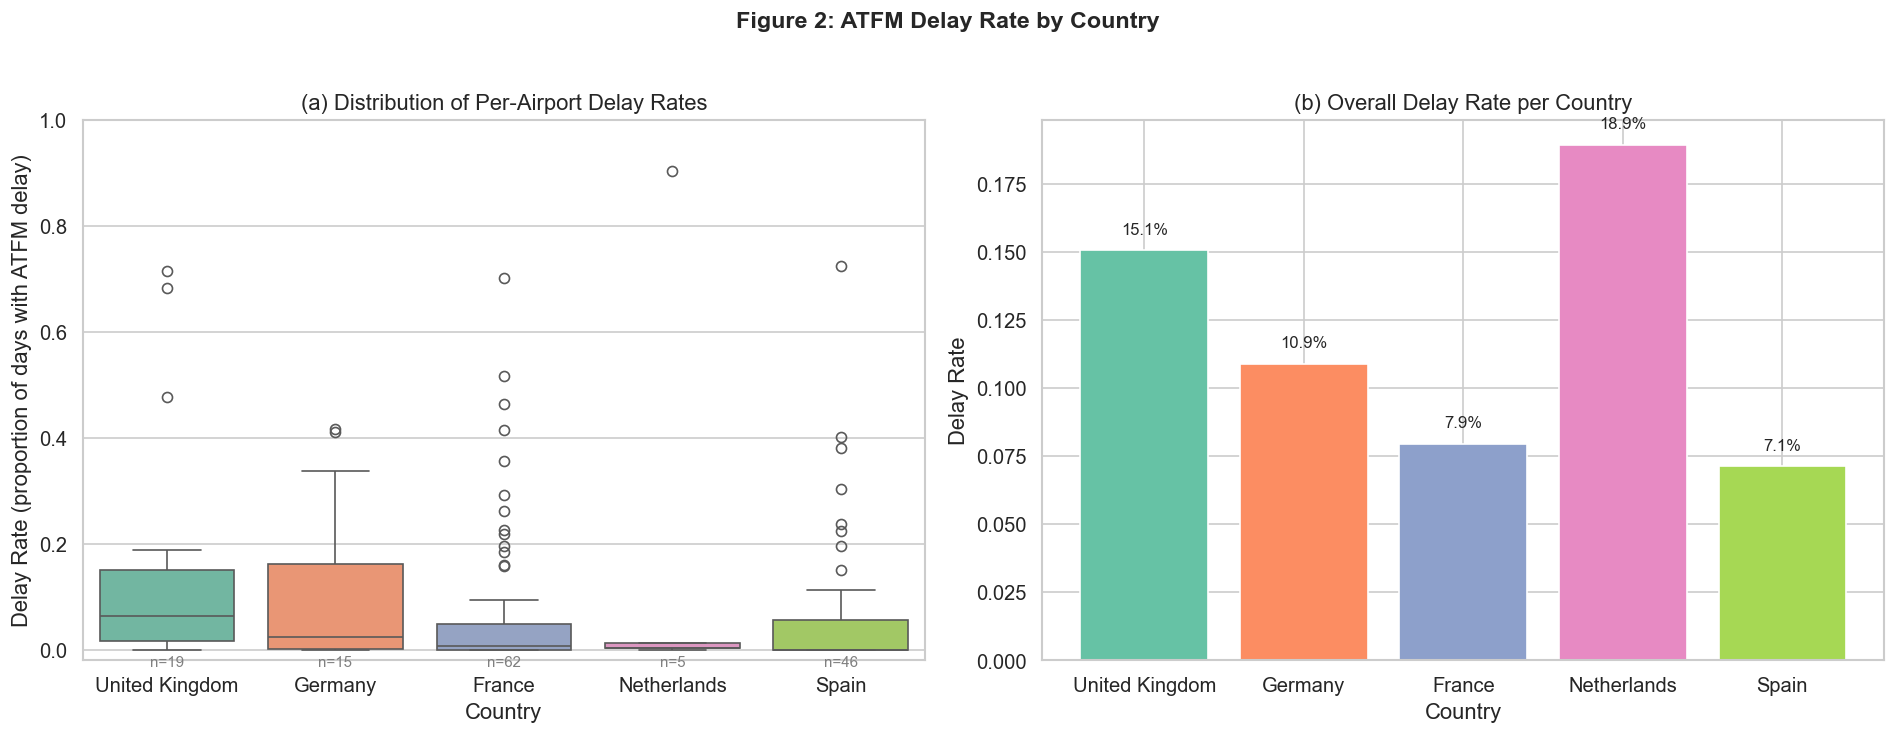

Saved: ..\figures\fig2_delay_by_country.png


In [8]:
# --- Figure 2: Delay rate by country (boxplot over airports) ---
country_order = (
    airport_agg.groupby("country")["delay_rate"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Boxplot of per-airport delay rates
sns.boxplot(
    data=airport_agg, x="country", y="delay_rate",
    order=country_order, palette="Set2", ax=axes[0]
)
axes[0].set_title("(a) Distribution of Per-Airport Delay Rates")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Delay Rate (proportion of days with ATFM delay)")
axes[0].set_ylim(-0.02, 1.0)

# Annotate with number of airports
for i, c in enumerate(country_order):
    n = airport_agg[airport_agg["country"] == c].shape[0]
    axes[0].text(i, -0.01, f"n={n}", ha="center", va="top", fontsize=9, color="gray")

# Panel B: Country-level aggregate delay rate (bar)
country_rate = df.groupby("country")["has_atfm_delay"].mean().reindex(country_order)
bars = axes[1].bar(country_rate.index, country_rate.values, color=sns.color_palette("Set2", 5))
axes[1].set_title("(b) Overall Delay Rate per Country")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Delay Rate")
for bar, val in zip(bars, country_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.1%}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Figure 2: ATFM Delay Rate by Country", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig2_delay_by_country.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig2_delay_by_country.png'}")

### Interpretation of Figure 2

Panel (a) shows the distribution of per-airport delay rates within each country. The boxplot
reveals substantial within-country variation: in every country, some airports rarely experience
ATFM delay while others are delayed on a large fraction of their operating days. The box width
and whisker length indicate that delay rates are not uniform even within a single country —
local factors (airport capacity, traffic volume, geographic weather exposure) matter as much as
country-level factors.

Panel (b) shows the overall country-level delay rate. The Netherlands has the highest rate,
which is expected: the Dutch network consists of only 5 airports, dominated by Amsterdam
Schiphol (EHAM), one of Europe's most capacity-constrained airports. France and Spain, despite
having many more airports, have lower aggregate rates because most of their medium-sized airports
rarely encounter ATFM restrictions.

**Key insight:** Country alone is not a strong predictor — within-country variation is large.
Airport-level features (traffic volume, runway capacity, hub status) likely carry more
predictive power than country identity.

### 5.3 Figure 3 — Seasonal Delay Patterns

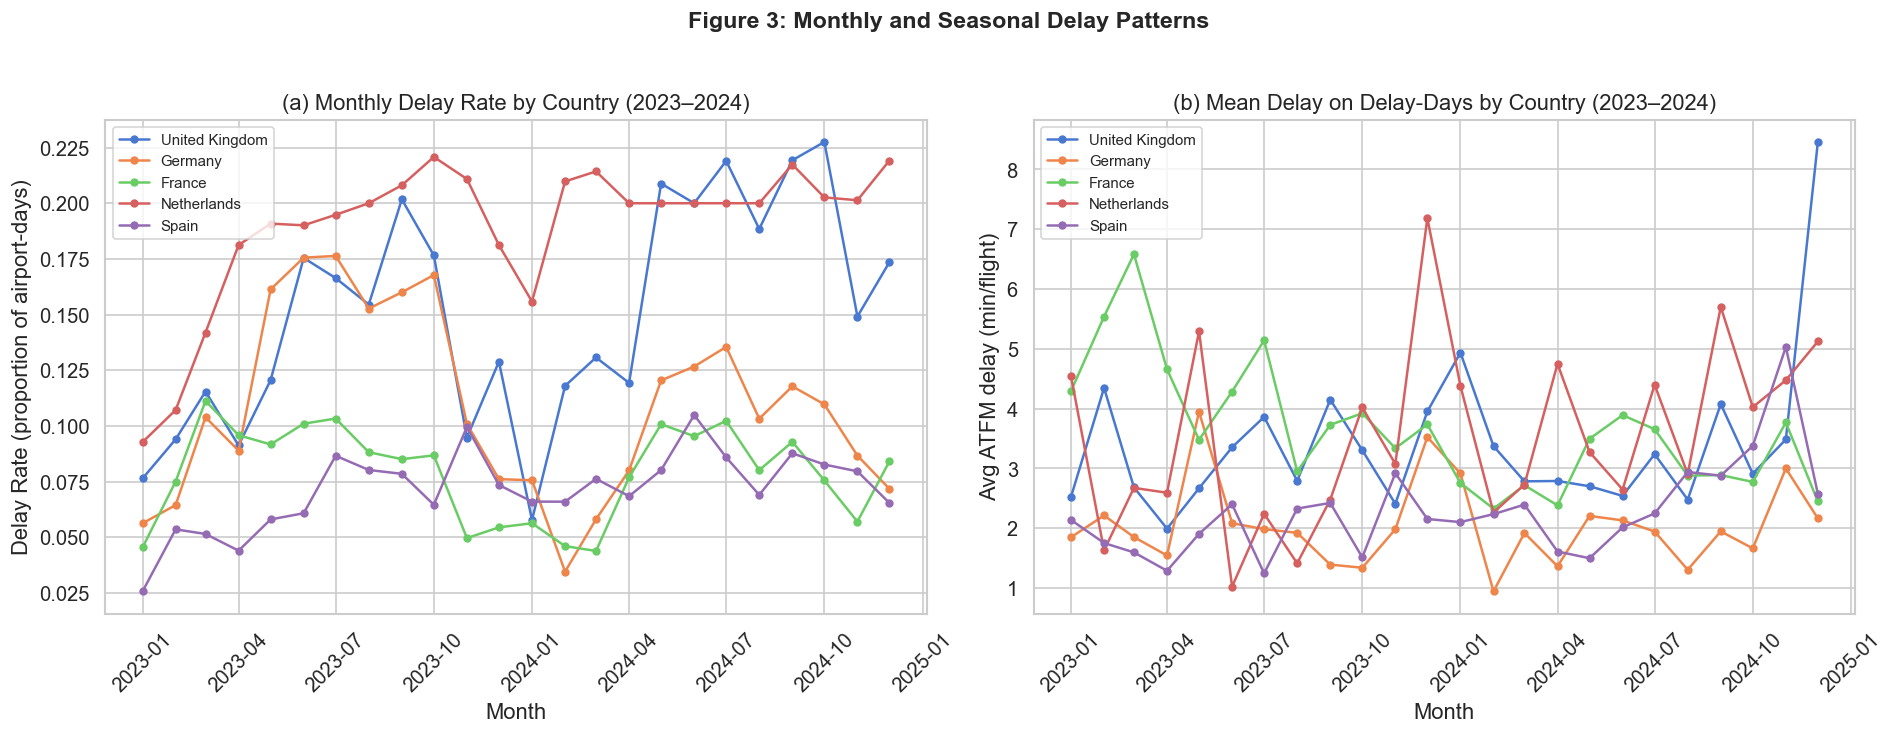

Saved: ..\figures\fig3_seasonal_delay.png


In [9]:
# --- Figure 3: Seasonal delay patterns (monthly line plot) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Delay rate over time by country
for country in country_order:
    subset = country_month[country_month["country"] == country]
    axes[0].plot(subset["year_month_dt"], subset["delay_rate"],
                 marker="o", markersize=4, label=country)

axes[0].set_title("(a) Monthly Delay Rate by Country (2023–2024)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Delay Rate (proportion of airport-days)")
axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=45)

# Panel B: Average delay per flight over time (only delay days)
delay_only = df[df["has_atfm_delay"] == 1].copy()
delay_monthly = delay_only.groupby(["country", "year_month"]).agg(
    mean_delay=("avg_atfm_delay_min", "mean"),
).reset_index()
delay_monthly["year_month_dt"] = delay_monthly["year_month"].dt.to_timestamp()

for country in country_order:
    subset = delay_monthly[delay_monthly["country"] == country]
    axes[1].plot(subset["year_month_dt"], subset["mean_delay"],
                 marker="o", markersize=4, label=country)

axes[1].set_title("(b) Mean Delay on Delay-Days by Country (2023–2024)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg ATFM delay (min/flight)")
axes[1].legend(fontsize=9)
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Figure 3: Monthly and Seasonal Delay Patterns",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig3_seasonal_delay.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig3_seasonal_delay.png'}")

### Interpretation of Figure 3

Panel (a) reveals a clear **summer peak** in delay rates across all five countries. The delay
rate rises sharply from April/May, peaks in June–August, and drops back in September/October.
This pattern is consistent across both 2023 and 2024, confirming it is a seasonal effect rather
than a one-off event. The summer peak reflects the well-documented surge in European air traffic
during the holiday season, which pushes busy airports beyond their declared capacity and triggers
ATFM regulations.

Panel (b) examines the **severity** of delay on days that actually have delay. Interestingly,
the severity does not follow the same clear seasonal curve as the frequency: some countries
show winter spikes in per-flight delay (likely weather-driven — fog, storms, de-icing), while
the summer delays, though more frequent, tend to be moderate in per-flight terms because
ATFM regulations spread the delay across many flights rather than concentrating it on a few.

**Key insight:** Temporal features (month, season, is_summer) will be important predictors
of whether delay occurs. The `is_summer` flag in particular is a strong candidate feature
for the classification model.

### 5.4 Figure 4 — Correlation Heatmap

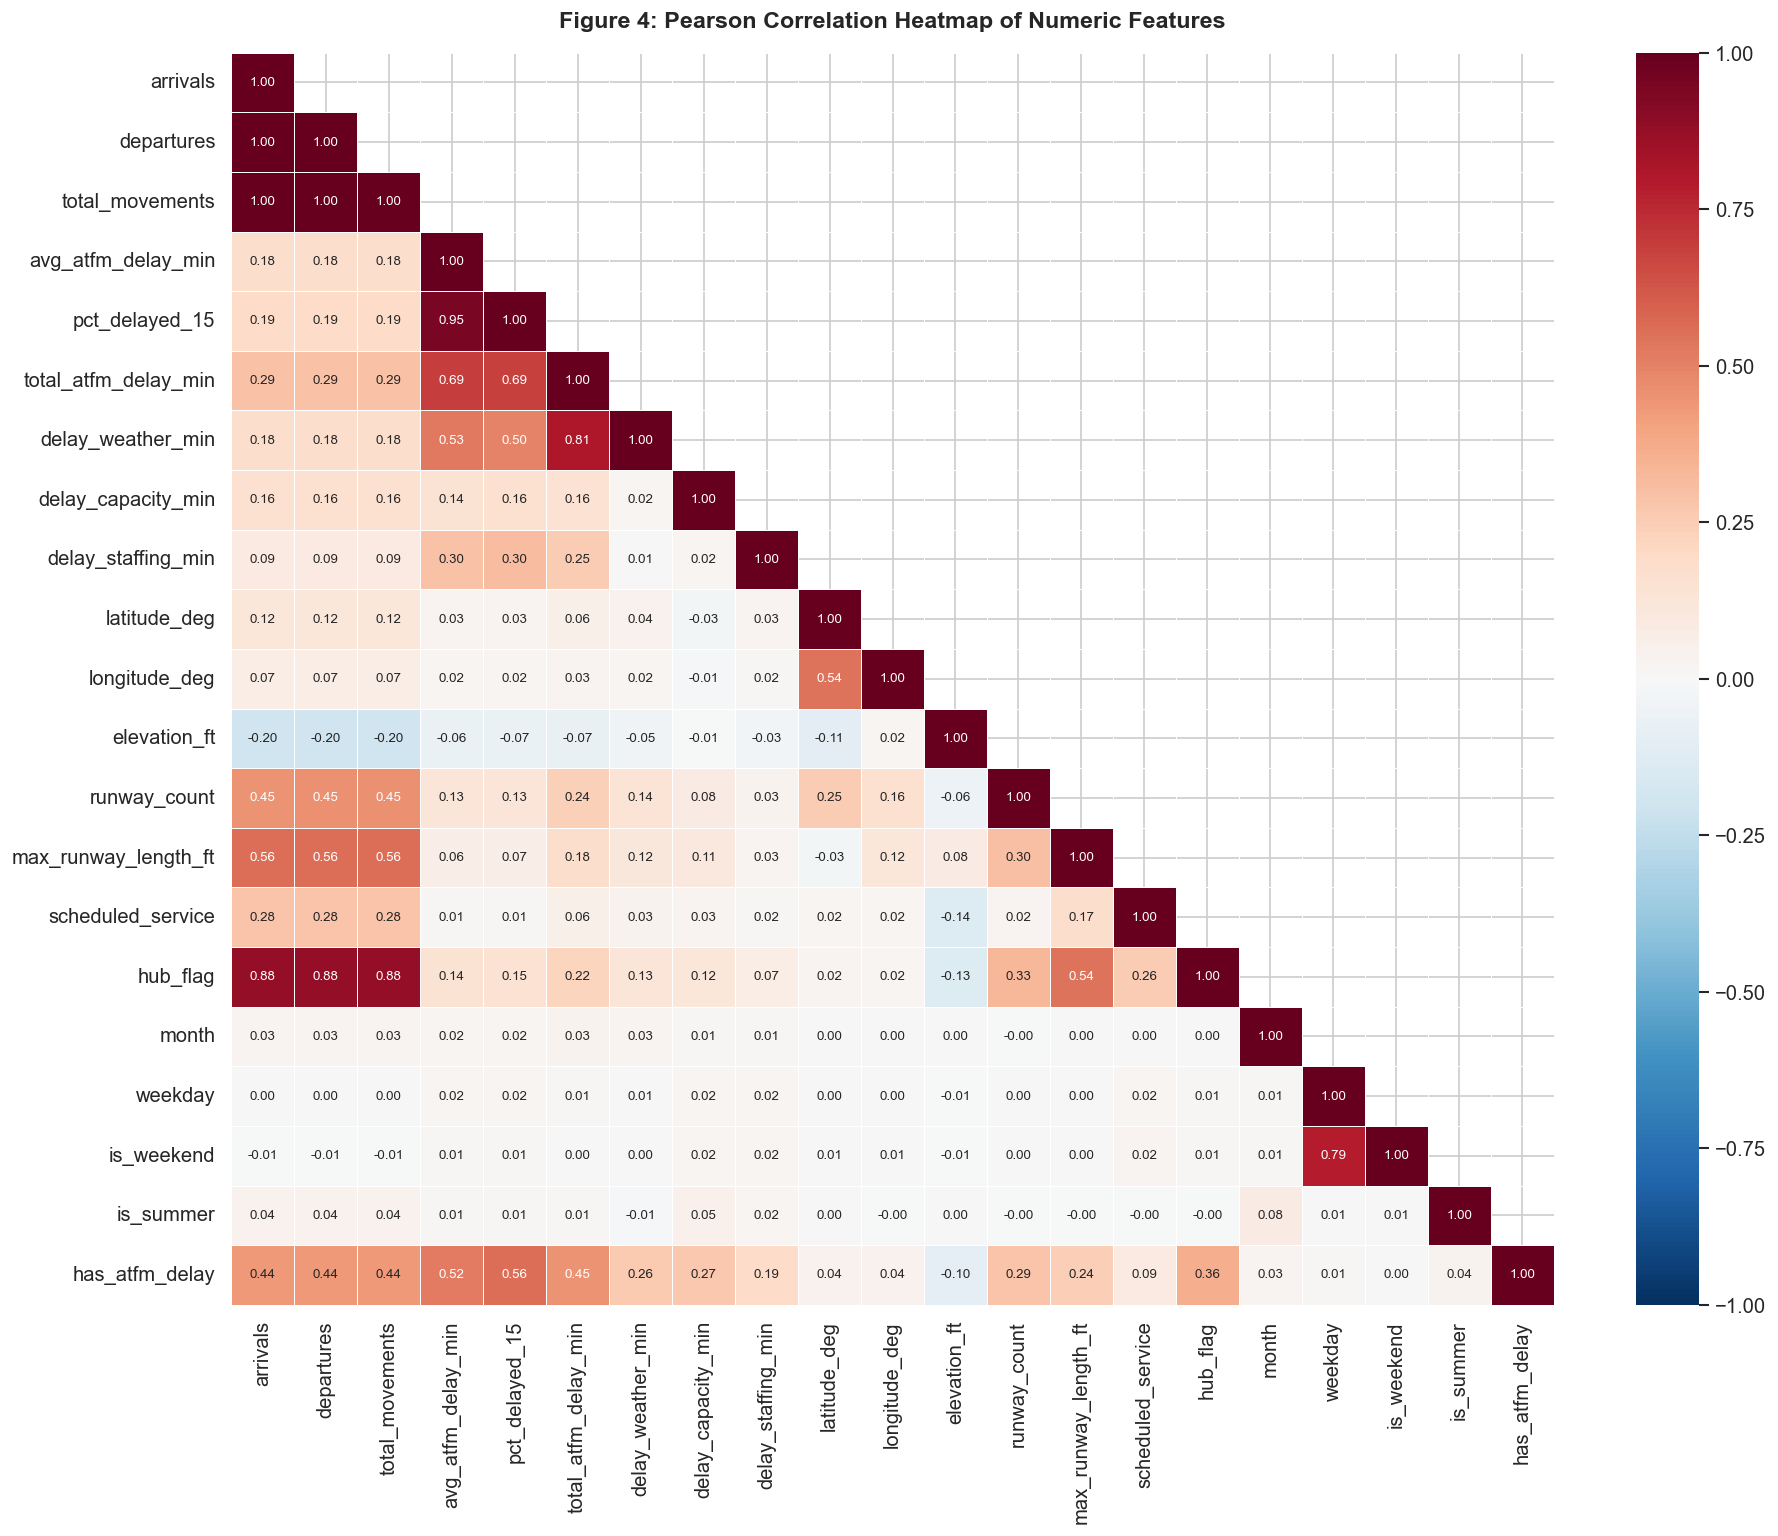

Saved: ..\figures\fig4_correlation_heatmap.png


In [10]:
# --- Figure 4: Correlation heatmap ---
# Select features relevant for modelling (exclude identifiers, redundant encodings, and date)
corr_cols = [
    "arrivals", "departures", "total_movements",
    "avg_atfm_delay_min", "pct_delayed_15", "total_atfm_delay_min",
    "delay_weather_min", "delay_capacity_min", "delay_staffing_min",
    "latitude_deg", "longitude_deg", "elevation_ft",
    "runway_count", "max_runway_length_ft",
    "scheduled_service", "hub_flag",
    "month", "weekday", "is_weekend", "is_summer",
    "has_atfm_delay",
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={"size": 8},
)
ax.set_title("Figure 4: Pearson Correlation Heatmap of Numeric Features",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig4_correlation_heatmap.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig4_correlation_heatmap.png'}")

### Interpretation of Figure 4

The correlation heatmap reveals several important patterns:

1. **Traffic features are highly correlated with each other.** `arrivals`, `departures`, and
   `total_movements` all correlate at r > 0.99, which is expected since an airport's daily
   departures closely match its arrivals. For modelling, we should use only one of these
   (e.g., `arrivals`) to avoid multicollinearity.

2. **Delay components correlate with each other and with the target.** `total_atfm_delay_min`,
   `avg_atfm_delay_min`, and `pct_delayed_15` are all correlated. The cause breakdown
   (`delay_weather_min`, `delay_capacity_min`, `delay_staffing_min`) also correlates with the
   total. Since these are component parts of the delay itself, they must be **excluded from
   the feature set** when modelling — they are leaky features that would not be available at
   prediction time.

3. **Hub status and traffic volume are positively correlated** with delay (both the continuous
   and binary versions). Busier airports experience more ATFM regulations — this makes sense
   because capacity limits are more likely to be reached at high-traffic airports.

4. **`is_summer` and `month` show weak positive correlation** with delay. The correlation is
   modest at the daily level because most days have zero delay, but the seasonal pattern visible
   in Figure 3 suggests these will still be useful features in a classification model.

5. **`weekday` and `is_weekend`** show near-zero correlation with delay, suggesting that
   day-of-week is not a strong linear predictor of ATFM delay.

6. **Airport infrastructure** (`runway_count`, `max_runway_length_ft`) correlates positively with
   `hub_flag` and traffic — large airports tend to have more and longer runways.

### 5.5 Figure 5 — Airport Type vs. Delay

C:\Users\abdal\AppData\Local\Temp\ipykernel_15720\2238392885.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\abdal\AppData\Local\Temp\ipykernel_15720\2238392885.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Large Airport", "Medium Airport"])


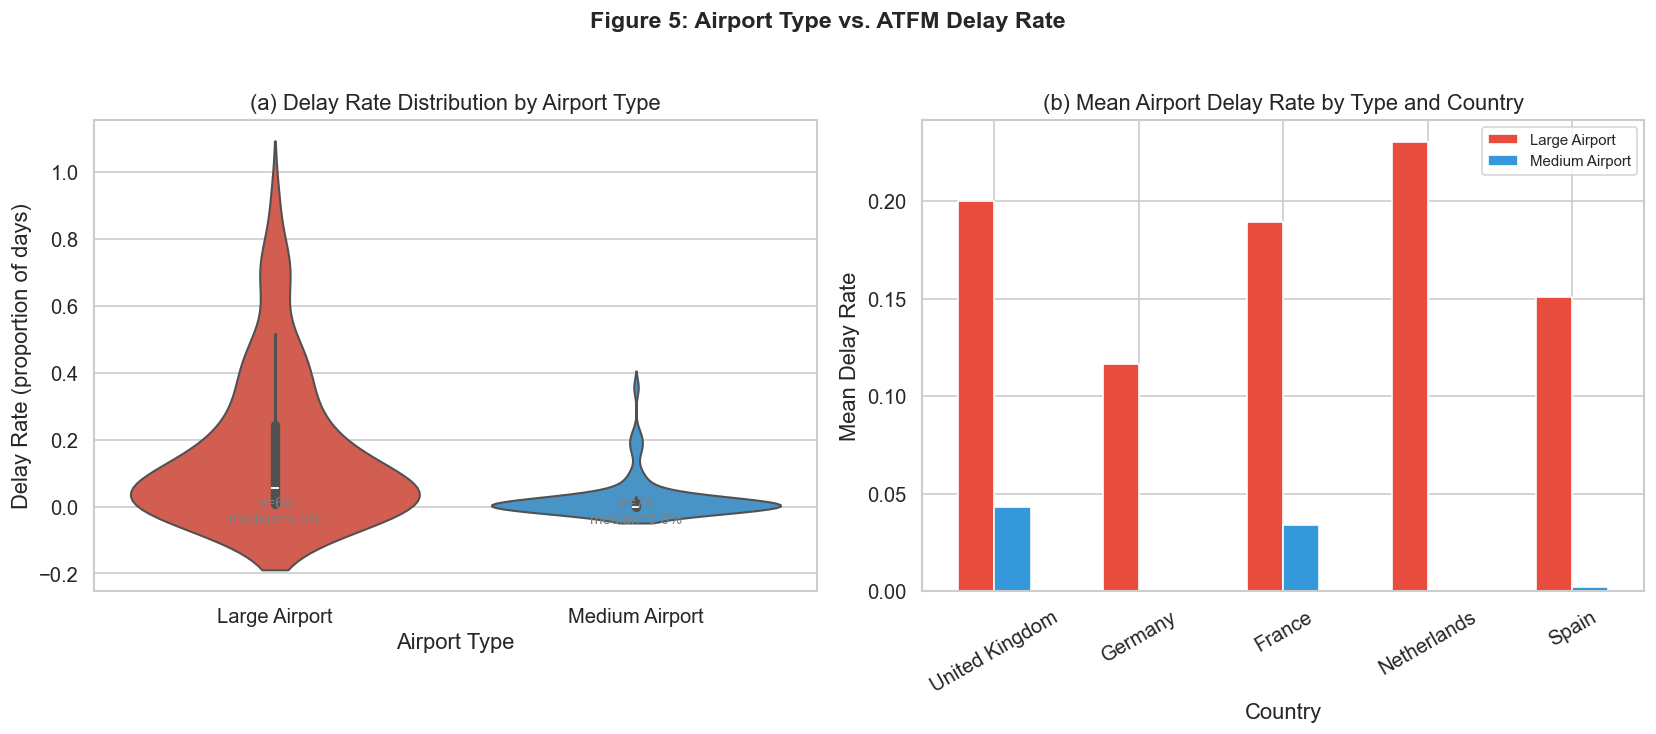

Saved: ..\figures\fig5_delay_by_airport_type.png


In [11]:
# --- Figure 5: Airport type vs. delay ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Delay rate by airport type (violin over airport-level data)
sns.violinplot(
    data=airport_agg, x="type", y="delay_rate",
    order=["large_airport", "medium_airport"],
    palette=["#e74c3c", "#3498db"], inner="box", ax=axes[0],
)
axes[0].set_title("(a) Delay Rate Distribution by Airport Type")
axes[0].set_xlabel("Airport Type")
axes[0].set_ylabel("Delay Rate (proportion of days)")
axes[0].set_xticklabels(["Large Airport", "Medium Airport"])

# Annotate with counts
for i, t in enumerate(["large_airport", "medium_airport"]):
    n = airport_agg[airport_agg["type"] == t].shape[0]
    med = airport_agg[airport_agg["type"] == t]["delay_rate"].median()
    axes[0].text(i, -0.05, f"n={n}\nmedian={med:.1%}", ha="center", fontsize=9, color="gray")

# Panel B: Delay rate by airport type AND country
type_country = airport_agg.groupby(["country", "type"])["delay_rate"].mean().unstack()
type_country = type_country.reindex(country_order)
type_country.plot(kind="bar", ax=axes[1], color=["#e74c3c", "#3498db"], edgecolor="white")
axes[1].set_title("(b) Mean Airport Delay Rate by Type and Country")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Mean Delay Rate")
axes[1].legend(["Large Airport", "Medium Airport"], fontsize=9)
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Figure 5: Airport Type vs. ATFM Delay Rate",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig5_delay_by_airport_type.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig5_delay_by_airport_type.png'}")

### Interpretation of Figure 5

Panel (a) shows that **large airports have substantially higher delay rates** than medium airports.
The violin shape for large airports is wider and extends to higher delay-rate values, while
most medium airports cluster near zero. This is expected: large airports handle more traffic,
operate closer to their declared capacity, and are therefore more frequently subject to ATFM
regulations.

Panel (b) breaks this pattern down by country. In every country, large airports have a higher
mean delay rate than medium airports, confirming the pattern is consistent across the dataset.
The gap is especially large in the Netherlands and the United Kingdom, where the large airports
(Schiphol, Heathrow, Gatwick) are among Europe's busiest.

**Key insight:** Airport type (`large_airport` vs. `medium_airport`) is a useful predictor of
delay occurrence. However, it partly serves as a proxy for traffic volume, so the model should
include both features and let the algorithm decide their relative importance.

### 5.6 Figure 6 — Traffic Volume vs. Delay

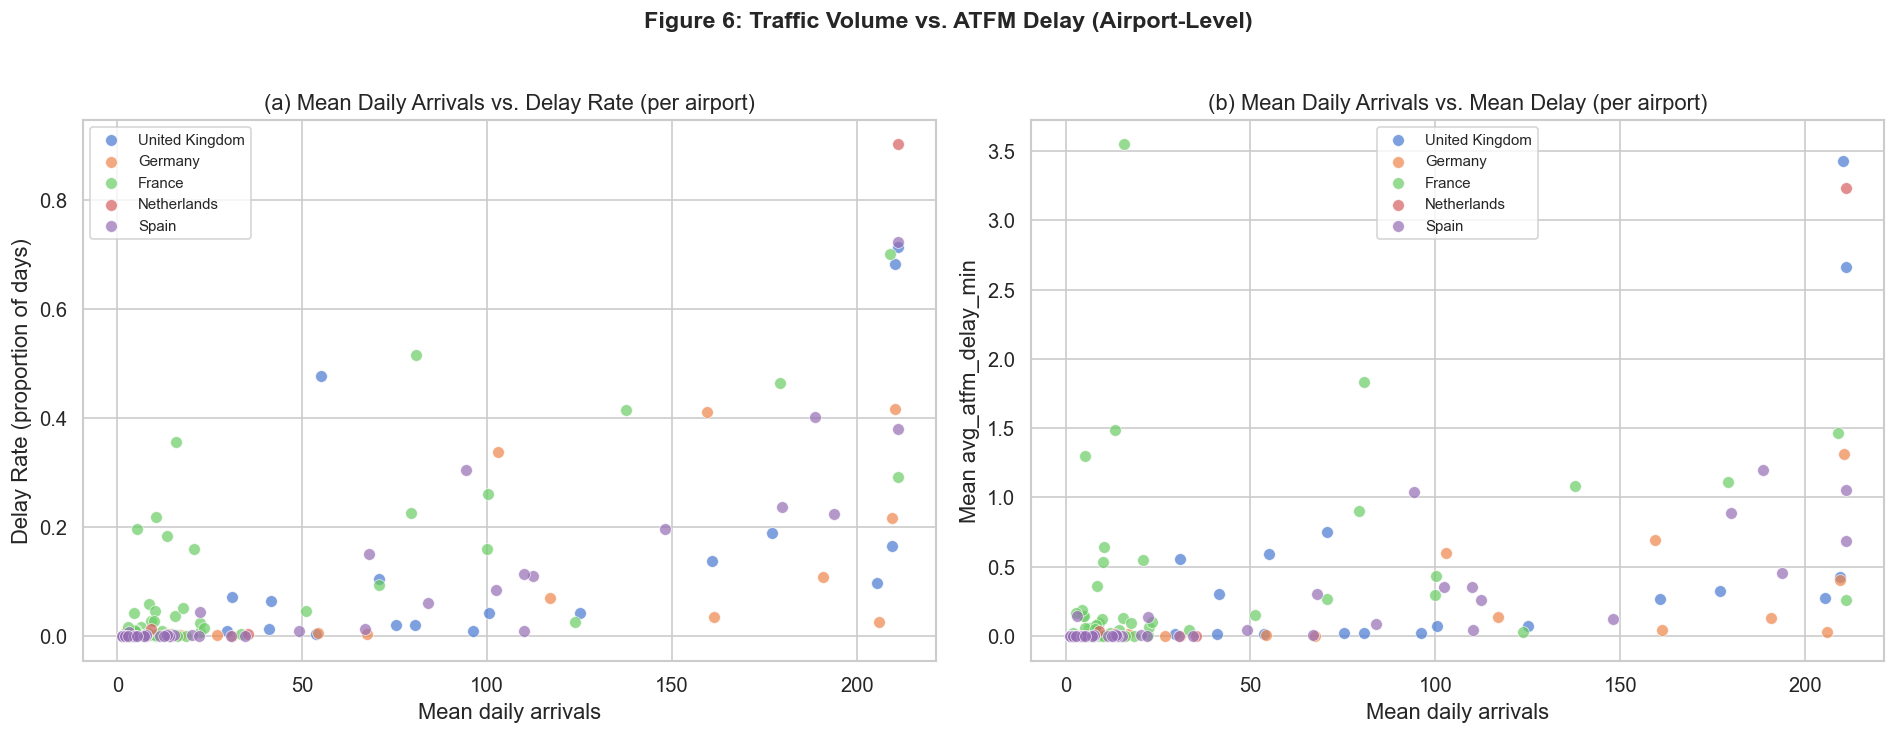

Saved: ..\figures\fig6_volume_vs_delay.png


In [12]:
# --- Figure 6: Traffic volume vs. delay (airport-level scatter) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Mean daily arrivals vs. delay rate (airport-level)
for country in country_order:
    subset = airport_agg[airport_agg["country"] == country]
    axes[0].scatter(
        subset["mean_arrivals"], subset["delay_rate"],
        label=country, alpha=0.7, s=50, edgecolors="white", linewidth=0.5,
    )
axes[0].set_title("(a) Mean Daily Arrivals vs. Delay Rate (per airport)")
axes[0].set_xlabel("Mean daily arrivals")
axes[0].set_ylabel("Delay Rate (proportion of days)")
axes[0].legend(fontsize=9)

# Panel B: Mean daily arrivals vs. mean delay (among delay days only)
for country in country_order:
    subset = airport_agg[airport_agg["country"] == country]
    axes[1].scatter(
        subset["mean_arrivals"], subset["mean_delay"],
        label=country, alpha=0.7, s=50, edgecolors="white", linewidth=0.5,
    )
axes[1].set_title("(b) Mean Daily Arrivals vs. Mean Delay (per airport)")
axes[1].set_xlabel("Mean daily arrivals")
axes[1].set_ylabel("Mean avg_atfm_delay_min")
axes[1].legend(fontsize=9)

plt.suptitle("Figure 6: Traffic Volume vs. ATFM Delay (Airport-Level)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig6_volume_vs_delay.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig6_volume_vs_delay.png'}")

### Interpretation of Figure 6

Panel (a) confirms a **positive relationship between traffic volume and delay rate**: airports
with more daily arrivals are more likely to experience ATFM delay on any given day. The
relationship is not perfectly linear — it appears to have a threshold effect where airports
below ~30 daily arrivals very rarely experience delay, while airports above ~100 daily arrivals
almost always have some delay days.

Panel (b) shows that the **severity** of delay (average minutes per flight, averaged over all days)
also increases with traffic volume, though with more scatter. The highest-traffic airports
cluster in the top-right, confirming they face both more frequent and more severe delays.

The scatter also shows that country-level clustering is partly explained by traffic: Dutch
airports cluster at high traffic volumes, while many French and Spanish airports are lower-traffic.

**Key insight:** `arrivals` (or `total_movements`) is likely one of the strongest predictors of
ATFM delay. However, the relationship may be non-linear, which could favour tree-based models
(decision tree, random forest) over linear models (logistic regression).

### 5.7 Figure 7 — Hub vs. Non-Hub Analysis

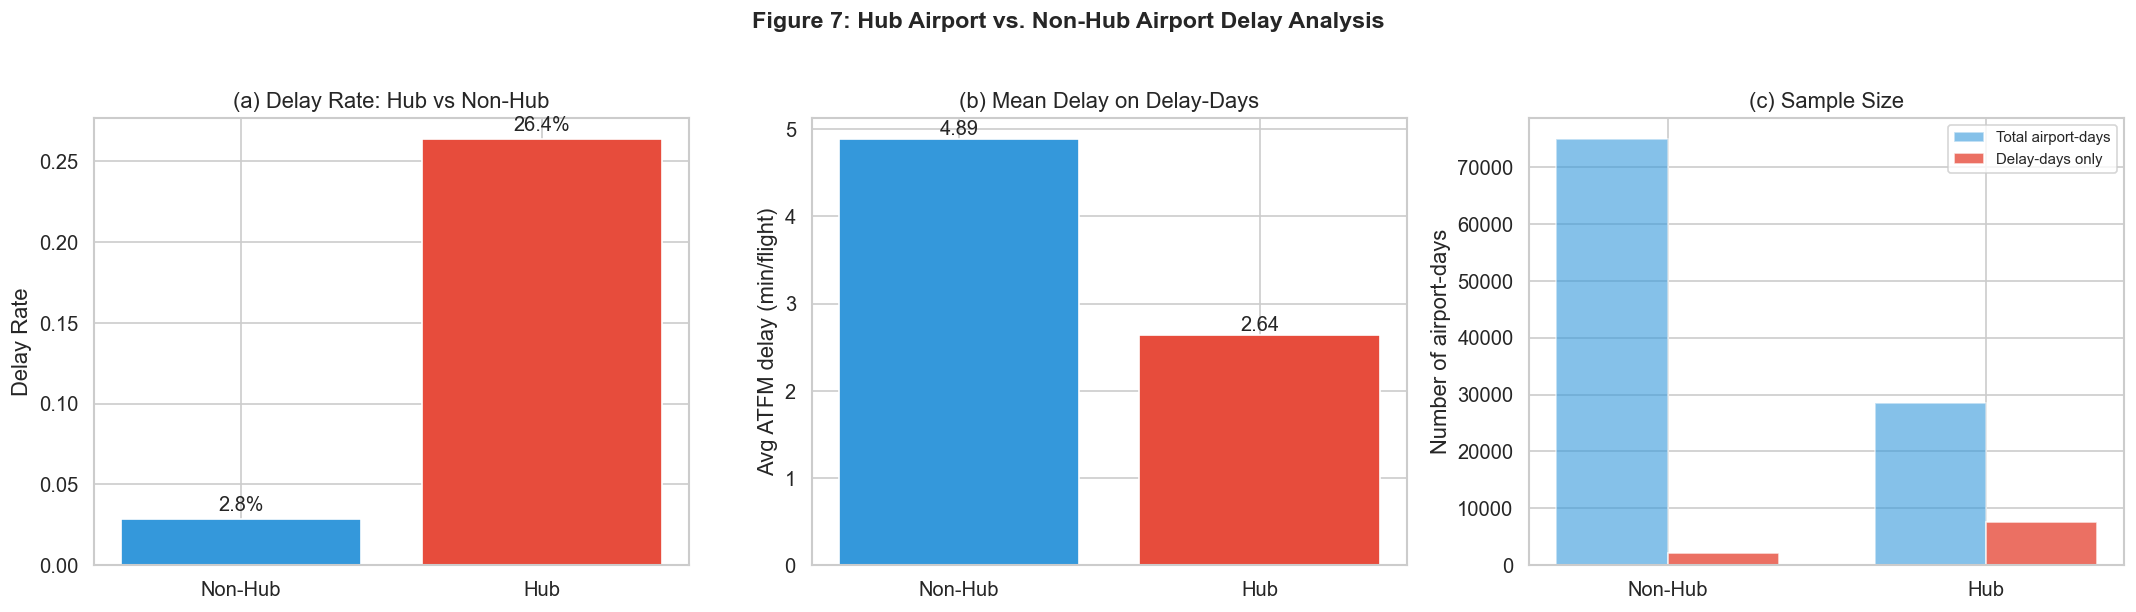

Saved: ..\figures\fig7_hub_analysis.png


In [13]:
# --- Figure 7: Hub vs. non-hub delay comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Delay rate comparison (daily-level)
hub_labels = {0: "Non-Hub", 1: "Hub"}
hub_rates = df.groupby("hub_flag")["has_atfm_delay"].mean()
bars = axes[0].bar(
    [hub_labels[k] for k in hub_rates.index],
    hub_rates.values,
    color=["#3498db", "#e74c3c"],
    edgecolor="white",
)
for bar, val in zip(bars, hub_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.1%}", ha="center", fontsize=12)
axes[0].set_title("(a) Delay Rate: Hub vs Non-Hub")
axes[0].set_ylabel("Delay Rate")

# Panel B: Mean delay when delay occurs
delay_only_hub = df[df["has_atfm_delay"] == 1].groupby("hub_flag")["avg_atfm_delay_min"].mean()
bars2 = axes[1].bar(
    [hub_labels[k] for k in delay_only_hub.index],
    delay_only_hub.values,
    color=["#3498db", "#e74c3c"],
    edgecolor="white",
)
for bar, val in zip(bars2, delay_only_hub.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val:.2f}", ha="center", fontsize=12)
axes[1].set_title("(b) Mean Delay on Delay-Days")
axes[1].set_ylabel("Avg ATFM delay (min/flight)")

# Panel C: Counts (how much data in each group)
hub_counts = df["hub_flag"].value_counts().sort_index()
hub_delay_counts = df[df["has_atfm_delay"] == 1]["hub_flag"].value_counts().sort_index()
x = np.arange(2)
w = 0.35
axes[2].bar(x - w/2, hub_counts.values, w, label="Total airport-days", color="#3498db", alpha=0.6)
axes[2].bar(x + w/2, hub_delay_counts.values, w, label="Delay-days only", color="#e74c3c", alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(["Non-Hub", "Hub"])
axes[2].set_title("(c) Sample Size")
axes[2].set_ylabel("Number of airport-days")
axes[2].legend(fontsize=9)

plt.suptitle("Figure 7: Hub Airport vs. Non-Hub Airport Delay Analysis",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig7_hub_analysis.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig7_hub_analysis.png'}")

### Interpretation of Figure 7

Panel (a) shows a dramatic difference: **hub airports are delayed far more frequently** than
non-hub airports. This is the single strongest binary predictor we have found so far.
Hub airports (those in the top 25% by average daily arrivals) face ATFM regulations on a much
larger fraction of their operating days.

Panel (b) shows that hub airports also experience **more severe delays** when delay does occur,
though the gap is smaller than the frequency gap. This means the relationship between hub
status and delay is primarily about *whether* delay happens, not just *how much*.

Panel (c) provides the sample sizes: hub airports account for a minority of the total
airport-days (because there are fewer hub airports), but they contribute the majority of
delay-days. This imbalance in the data is important for model evaluation — a model that
simply predicts "no delay for all non-hub airport-days" would achieve high accuracy but
miss most of the delay events at hubs.

**Key insight:** `hub_flag` will be a strong binary feature for the classification model.
It effectively encodes whether an airport is capacity-constrained, which is the fundamental
driver of ATFM delay.

### 5.8 Figure 8 — Geographic Distribution of Delays

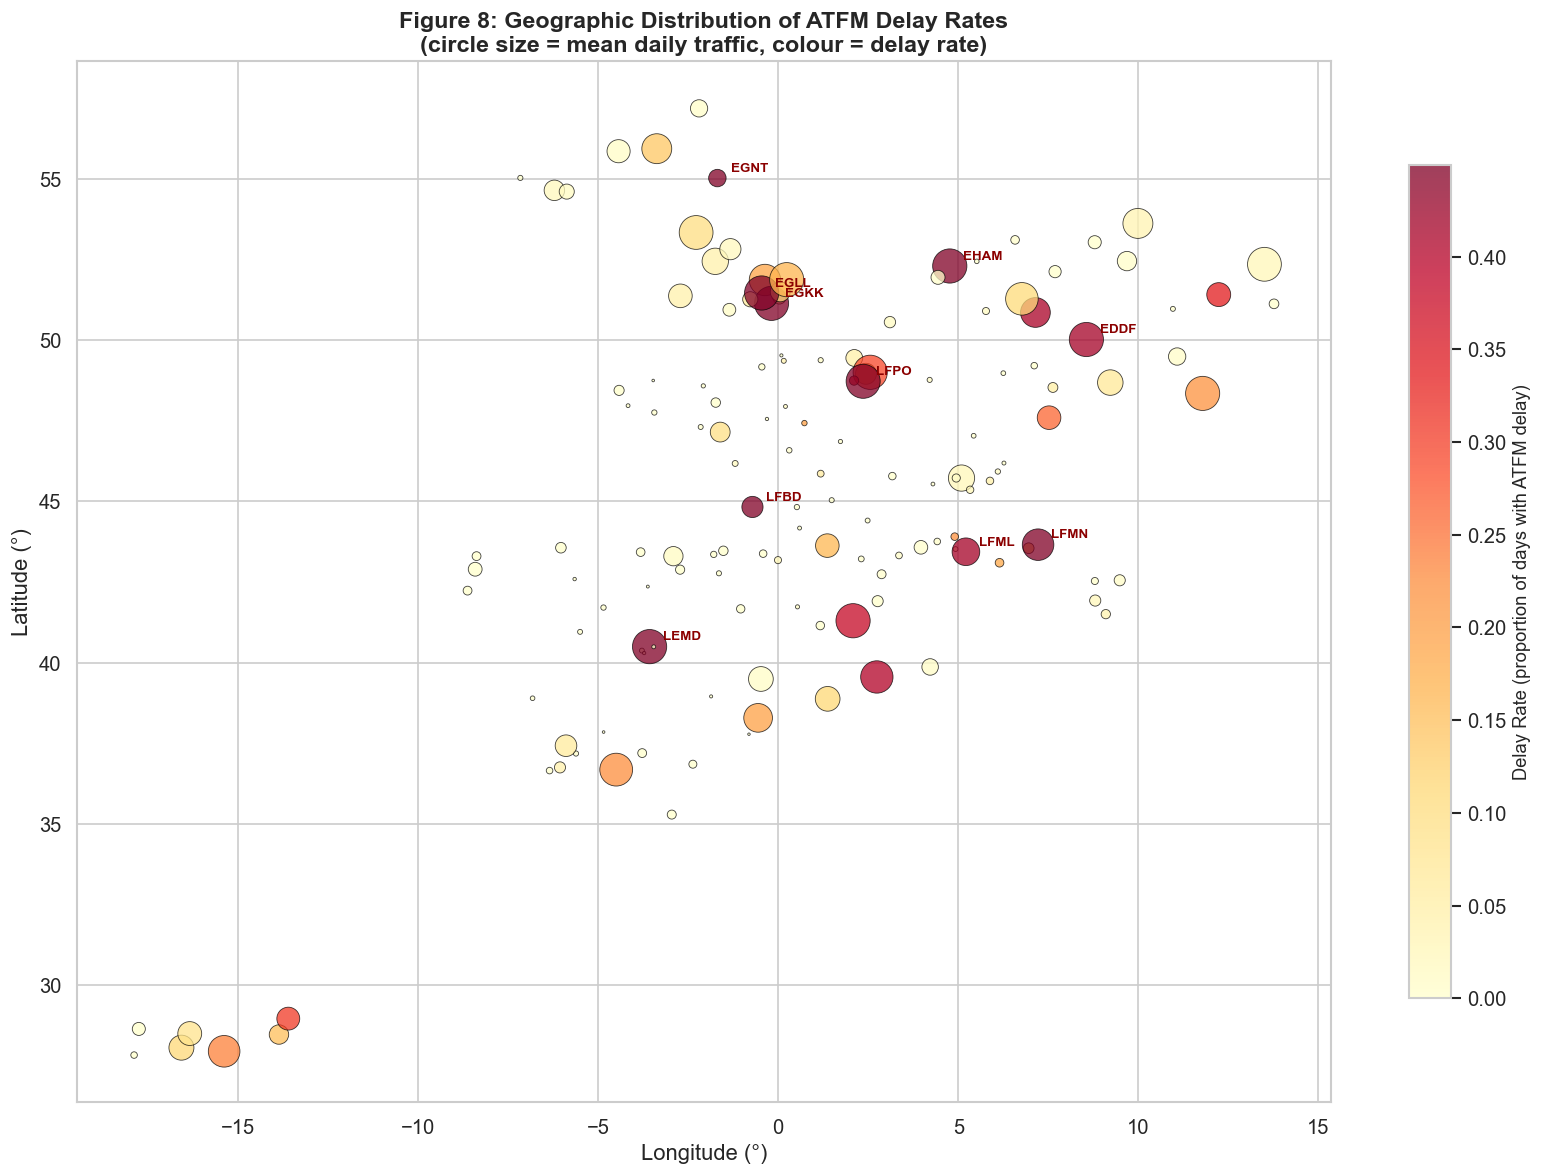

Saved: ..\figures\fig8_geographic_delays.png


In [14]:
# --- Figure 8: Geographic scatter plot ---
fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(
    airport_agg["longitude_deg"],
    airport_agg["latitude_deg"],
    c=airport_agg["delay_rate"],
    s=airport_agg["mean_arrivals"] * 2,  # size proportional to traffic
    cmap="YlOrRd",
    alpha=0.75,
    edgecolors="black",
    linewidth=0.5,
    vmin=0,
    vmax=airport_agg["delay_rate"].quantile(0.95),
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label("Delay Rate (proportion of days with ATFM delay)", fontsize=11)

# Label the top 10 most delayed airports
top10 = airport_agg.nlargest(10, "delay_rate")
for _, row in top10.iterrows():
    ax.annotate(
        row["icao_code"],
        (row["longitude_deg"], row["latitude_deg"]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=8,
        color="darkred",
        fontweight="bold",
    )

ax.set_title("Figure 8: Geographic Distribution of ATFM Delay Rates\n"
             "(circle size = mean daily traffic, colour = delay rate)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig8_geographic_delays.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig8_geographic_delays.png'}")

### Interpretation of Figure 8

The geographic scatter plot encodes three dimensions: longitude and latitude define position,
circle size represents mean daily traffic volume, and colour represents the delay rate.

Several patterns emerge:

- The **highest delay rates** (dark red, labelled) concentrate at the major hub airports:
  the large circles in northwest Europe (London, Amsterdam, Paris) and the Mediterranean
  (southern Spain, Canary Islands). These airports combine high traffic with constrained
  capacity.
- The many **small, light-coloured circles** scattered across France and Spain represent
  medium-sized airports that operate well below capacity and rarely face ATFM restrictions.
- There is no obvious latitude-based gradient (north vs. south delay), suggesting that
  geographic position per se is not a primary driver. Rather, delay correlates with the
  **size of the circle** (traffic) more than its position.

**Key insight:** While latitude and longitude provide some geographic context, they are
primarily proxies for which specific airport the observation belongs to. The geographic
features may help a tree-based model learn airport-specific splits, but they should not
be over-interpreted as causal factors.

### 5.9 Figure 9 — Delay Cause Breakdown by Country

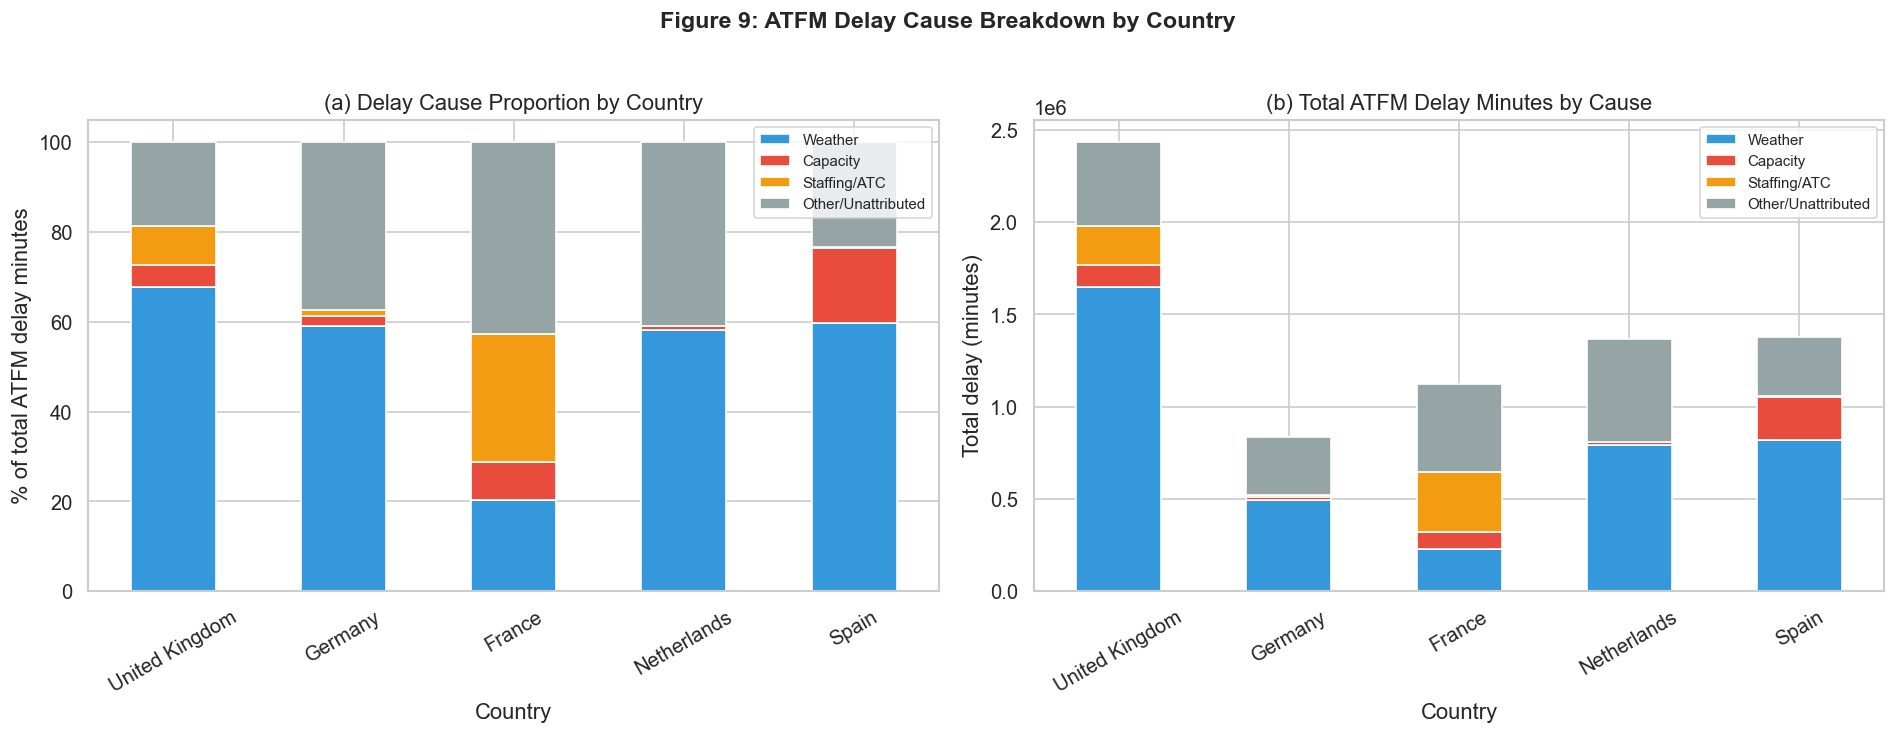

Saved: ..\figures\fig9_delay_causes.png


In [15]:
# --- Figure 9: Delay cause breakdown ---
# Aggregate total delay minutes by cause and country (only delay-days)
cause_cols = ["delay_weather_min", "delay_capacity_min", "delay_staffing_min"]
cause_labels = ["Weather", "Capacity", "Staffing/ATC"]

cause_by_country = (
    df[df["has_atfm_delay"] == 1]
    .groupby("country")[cause_cols]
    .sum()
    .reindex(country_order)
)

# Compute "Other" as total minus the three known causes
total_by_country = (
    df[df["has_atfm_delay"] == 1]
    .groupby("country")["total_atfm_delay_min"]
    .sum()
    .reindex(country_order)
)
cause_by_country["delay_other_min"] = (
    total_by_country - cause_by_country.sum(axis=1)
).clip(lower=0)

all_causes = cause_cols + ["delay_other_min"]
all_labels = cause_labels + ["Other/Unattributed"]

# Normalise to percentages
cause_pct = cause_by_country[all_causes].div(cause_by_country[all_causes].sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Stacked bar (percentage)
cause_pct.plot(kind="bar", stacked=True, ax=axes[0],
               color=["#3498db", "#e74c3c", "#f39c12", "#95a5a6"],
               edgecolor="white")
axes[0].set_title("(a) Delay Cause Proportion by Country")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("% of total ATFM delay minutes")
axes[0].legend(all_labels, fontsize=9, loc="upper right")
axes[0].tick_params(axis="x", rotation=30)

# Panel B: Total delay minutes by cause (absolute)
cause_by_country[all_causes].plot(kind="bar", stacked=True, ax=axes[1],
                                   color=["#3498db", "#e74c3c", "#f39c12", "#95a5a6"],
                                   edgecolor="white")
axes[1].set_title("(b) Total ATFM Delay Minutes by Cause")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Total delay (minutes)")
axes[1].legend(all_labels, fontsize=9, loc="upper right")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Figure 9: ATFM Delay Cause Breakdown by Country",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig9_delay_causes.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig9_delay_causes.png'}")

### Interpretation of Figure 9

Panel (a) shows that the **relative mix of delay causes varies substantially between countries.**
Weather is the dominant cause of ATFM delay in some countries, while staffing/ATC issues
dominate in others. This variation suggests that delay cause features could be useful for
understanding delay patterns, but since the cause is only known *after* the delay has occurred,
these columns cannot be used as input features for a predictive model — they are the explanation,
not the predictor.

Panel (b) shows the **absolute volume** of delay minutes. France and the United Kingdom
contribute the largest total delay minutes, reflecting both their high traffic volumes and
their complex airspace structures. The Netherlands, despite its high delay rate per airport-day,
contributes fewer total minutes because it has fewer airports.

**Key insight:** The cause breakdown columns (`delay_weather_min`, `delay_capacity_min`,
`delay_staffing_min`) are **leaky features** — they describe the delay itself and would not be
known at prediction time. They must be excluded from the feature set in Phase 4. We note their
patterns here for interpretive purposes only.

**Limitation:** The EUROCONTROL data reports three specific cause categories (weather, capacity,
staffing), but the total ATFM delay may also include causes not captured in these columns
(shown as "Other/Unattributed"). The sum of the three causes does not always equal the total
delay minutes.

---

## 6. Key Findings Summary

In [16]:
print("=" * 70)
print("KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS")
print("=" * 70)

findings = [
    ("1. Zero-inflated target",
     "90.7% of airport-days have zero ATFM delay. This makes "
     "regression impractical and favours binary classification."),

    ("2. Target variable chosen",
     "has_atfm_delay (1 if total_atfm_delay_min > 0, else 0). "
     f"Class balance: {n_neg/len(df)*100:.1f}% negative, "
     f"{n_pos/len(df)*100:.1f}% positive — imbalanced ({n_neg/n_pos:.1f}:1 ratio)."),

    ("3. Strong summer seasonality",
     "Delay rate peaks in June–August across all five countries, "
     "driven by increased holiday traffic. Month and is_summer "
     "are important temporal features."),

    ("4. Hub status is the strongest single predictor",
     "Hub airports experience dramatically higher delay rates "
     "than non-hub airports. The hub_flag feature captures "
     "whether an airport is capacity-constrained."),

    ("5. Traffic volume drives delay",
     "Airports with more daily arrivals are more likely to face "
     "ATFM restrictions. The relationship appears non-linear, "
     "favouring tree-based models."),

    ("6. Large airports are delayed more than medium airports",
     "Airport type (large vs. medium) is a useful predictor, "
     "though partly redundant with traffic volume and hub status."),

    ("7. Within-country variation exceeds between-country variation",
     "Country alone is not a strong predictor. Airport-level features "
     "(traffic, hub status, runway capacity) carry more predictive power."),

    ("8. Delay causes are leaky features",
     "delay_weather_min, delay_capacity_min, and delay_staffing_min "
     "describe the delay itself and must be excluded from the model input."),

    ("9. Multicollinearity among traffic features",
     "arrivals, departures, and total_movements are nearly perfectly "
     "correlated (r > 0.99). Only one should be kept for modelling."),
]

for title, text in findings:
    print(f"\n{title}")
    print(f"  {text}")

KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS

1. Zero-inflated target
  90.7% of airport-days have zero ATFM delay. This makes regression impractical and favours binary classification.

2. Target variable chosen
  has_atfm_delay (1 if total_atfm_delay_min > 0, else 0). Class balance: 90.7% negative, 9.3% positive — imbalanced (9.7:1 ratio).

3. Strong summer seasonality
  Delay rate peaks in June–August across all five countries, driven by increased holiday traffic. Month and is_summer are important temporal features.

4. Hub status is the strongest single predictor
  Hub airports experience dramatically higher delay rates than non-hub airports. The hub_flag feature captures whether an airport is capacity-constrained.

5. Traffic volume drives delay
  Airports with more daily arrivals are more likely to face ATFM restrictions. The relationship appears non-linear, favouring tree-based models.

6. Large airports are delayed more than medium airports
  Airport type (large vs. medium) is a 

## 7. Recommended Modelling Strategy for Phase 4

Based on the EDA findings above, we recommend the following strategy:

### Target Variable
- **`has_atfm_delay`** — binary classification (1 = ATFM delay imposed, 0 = no delay)

### Candidate Features (no leakage)

| Feature | Type | Rationale |
|---|---|---|
| `arrivals` | Numeric | Strongest traffic predictor; drop `departures`/`total_movements` to avoid multicollinearity |
| `hub_flag` | Binary | Strong predictor of delay frequency |
| `month` | Numeric | Captures seasonal patterns |
| `is_summer` | Binary | Captures the peak delay season |
| `weekday` | Numeric | Day-of-week effects (weak but worth including) |
| `is_weekend` | Binary | Simplified weekday effect |
| `latitude_deg` | Numeric | Geographic proxy for airport identity |
| `longitude_deg` | Numeric | Geographic proxy |
| `elevation_ft` | Numeric | Physical airport characteristic |
| `runway_count` | Numeric | Infrastructure capacity indicator |
| `max_runway_length_ft` | Numeric | Infrastructure characteristic |
| `scheduled_service` | Binary | Whether the airport offers scheduled flights |
| `type` (encoded) | Binary | Large vs. medium airport |
| `country` (encoded) | Categorical | One-hot encoded, 5 countries |
| `season_encoded` | Ordinal | Seasonal cycle |
| `traffic_volume_encoded` | Ordinal | Discretised traffic level |

**Features to EXCLUDE:**
- `total_atfm_delay_min`, `avg_atfm_delay_min`, `pct_delayed_15` — these ARE the target (leakage)
- `delay_weather_min`, `delay_capacity_min`, `delay_staffing_min` — cause components of the target (leakage)
- `flights_with_delay`, `flights_delayed_15` — direct count of delayed flights (leakage)
- `departures`, `total_movements` — redundant with `arrivals` (multicollinearity)

### Models to Train (Phase 4)
1. **Logistic Regression** — linear baseline
2. **Decision Tree** — interpretable, handles non-linear relationships
3. **Random Forest** — ensemble, expected best performance

### Evaluation Metrics
Given the class imbalance (~9:1), **accuracy is misleading** (a naive "predict 0" baseline
achieves ~90.7%). We will report:
- **Precision, Recall, F1-score** (per class and weighted)
- **AUC-ROC** (area under the receiver operating characteristic curve)
- **Confusion matrix**

### Handling Imbalance
- **Stratified train/test split** to preserve class proportions
- **`class_weight='balanced'`** in scikit-learn models

---

## Figures Summary

| # | Figure | File |
|---|---|---|
| 1 | Target Variable Distribution | `fig1_target_distribution.png` |
| 2 | Delay Rate by Country | `fig2_delay_by_country.png` |
| 3 | Seasonal Delay Patterns | `fig3_seasonal_delay.png` |
| 4 | Correlation Heatmap | `fig4_correlation_heatmap.png` |
| 5 | Airport Type vs. Delay | `fig5_delay_by_airport_type.png` |
| 6 | Traffic Volume vs. Delay | `fig6_volume_vs_delay.png` |
| 7 | Hub vs. Non-Hub Analysis | `fig7_hub_analysis.png` |
| 8 | Geographic Delay Distribution | `fig8_geographic_delays.png` |
| 9 | Delay Cause Breakdown | `fig9_delay_causes.png` |